In [1]:
import numpy as np 
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
import myfun as wf
import math, gc, logging,os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter
import geocat.viz as gv

In [2]:
if __name__ == "__main__":
    fpath_in0 = "/glade/derecho/scratch/hcluo/GMS/"
    fpath_in1 = "/glade/derecho/scratch/hcluo/vMSE_col_MMC/"
    years = np.arange(1997,2024)
    fnames1 = []
    fnames2 = []
    for i in years:
        fnames1.append(fpath_in0+"v_MMC_col"+f"{i}.nc")
        fnames2.append(fpath_in1+"vMSE_col_MMC_"+f"{i}.nc")

DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/glade/u/home/hcluo/miniconda3/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansDisplay.ttf', name='DejaVu Sans Display', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/glade/u/home/hcluo/miniconda3/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizFourSymReg.ttf', name='STIXSizeFourSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/glade/u/home/hcluo/minico

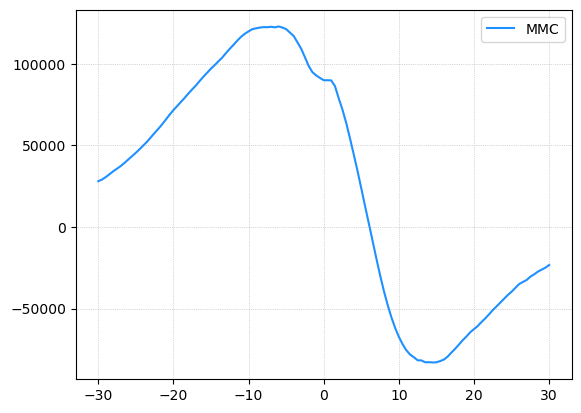

In [3]:
#v_MMC_col = xr.open_dataset(fpath_in0+"v_MMC_col.nc")["v_MMC_col"].mean(["time","longitude"])
a = 6371.0e3
v_MMC_col = xr.open_mfdataset(fnames1,concat_dim = 'time', combine='nested')["v_MMC_col"].mean(["time","longitude"]).sel(latitude = slice(-30,30))
vMSE_MMC_col = xr.open_mfdataset(fnames2,concat_dim = 'time', combine='nested')["vMSE_MMC_col"].mean(["time","longitude"]).sel(latitude = slice(-30,30))
plt.plot(v_MMC_col.latitude,2*a*np.pi*np.cos(v_MMC_col.latitude/180*np.pi)*v_MMC_col/1.0e6,"dodgerblue",label = "MMC")
plt.legend()
plt.grid(linestyle = ':', linewidth = 0.5)
#plt.ylim(-1.0e4,1.0e4)

(-10.0, 10.0)

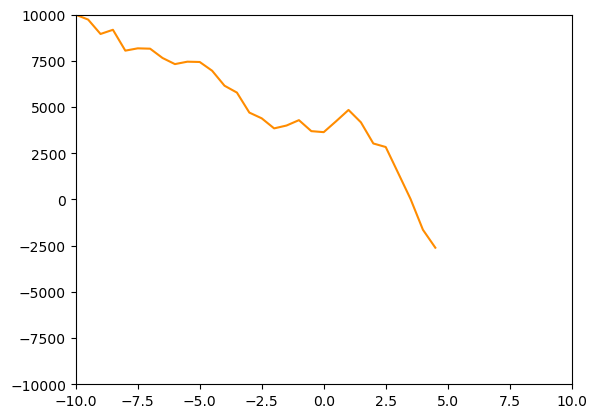

In [5]:
plt.plot(vMSE_MMC_col.sel(latitude = slice(-30,4.5)).latitude,-(vMSE_MMC_col/v_MMC_col).sel(latitude = slice(-30,4.5)),"darkorange",label = "transient")
plt.plot(vMSE_MMC_col.sel(latitude = slice(7.5,30)).latitude,-(vMSE_MMC_col/v_MMC_col).sel(latitude = slice(7.5,30)),"darkorange",label = "transient")
plt.ylim(-10000,10000)
plt.xlim(-10,10)